Matplotlib is building the font cache; this may take a moment.


Размер изображения: 1000 x 563 пикселей
Диапазон яркости: 0 ... 255


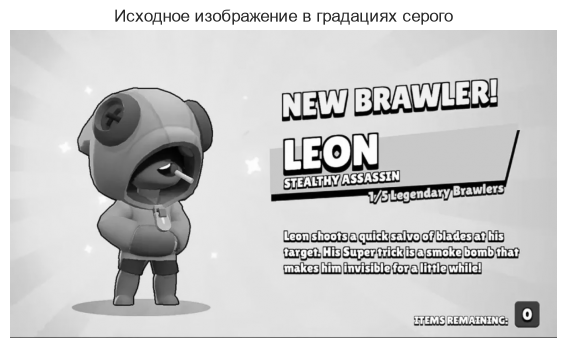

In [ ]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
IMAGE_PATH = Path('image.png')
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f'Не найден файл {IMAGE_PATH.resolve()}')

image = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_GRAYSCALE)
if image is None:
    raise ValueError('OpenCV не смогла прочитать изображение')

height, width = image.shape
print(f'Размер изображения: {width} x {height} пикселей')
print(f'Диапазон яркости: {image.min()} ... {image.max()}')

plt.figure(figsize=(8, 4))
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title('Исходное изображение в градациях серого')
plt.axis('off')
plt.show()

Пик гистограммы: интенсивность 225, 40765 пикс.


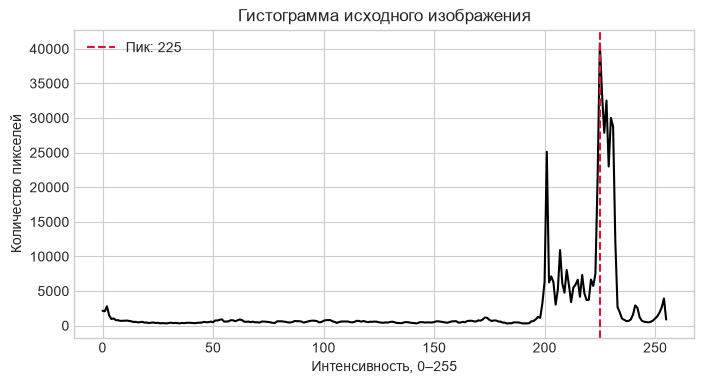

In [2]:
histogram = cv2.calcHist([image], [0], None, [256], [0, 256]).ravel()
peak_intensity = int(np.argmax(histogram))
peak_count = int(histogram[peak_intensity])
print(f'Пик гистограммы: интенсивность {peak_intensity}, {peak_count} пикс.')

plt.figure(figsize=(8, 4))
plt.plot(np.arange(256), histogram, color='black')
plt.axvline(peak_intensity, color='crimson', linestyle='--', label=f'Пик: {peak_intensity}')
plt.title('Гистограмма исходного изображения')
plt.xlabel('Интенсивность, 0–255')
plt.ylabel('Количество пикселей')
plt.legend()
plt.show()

Максимум горизонтального профиля Лапласа: строка 562, 230.83
Максимум вертикального профиля Лапласа: столбец 535, 57.45


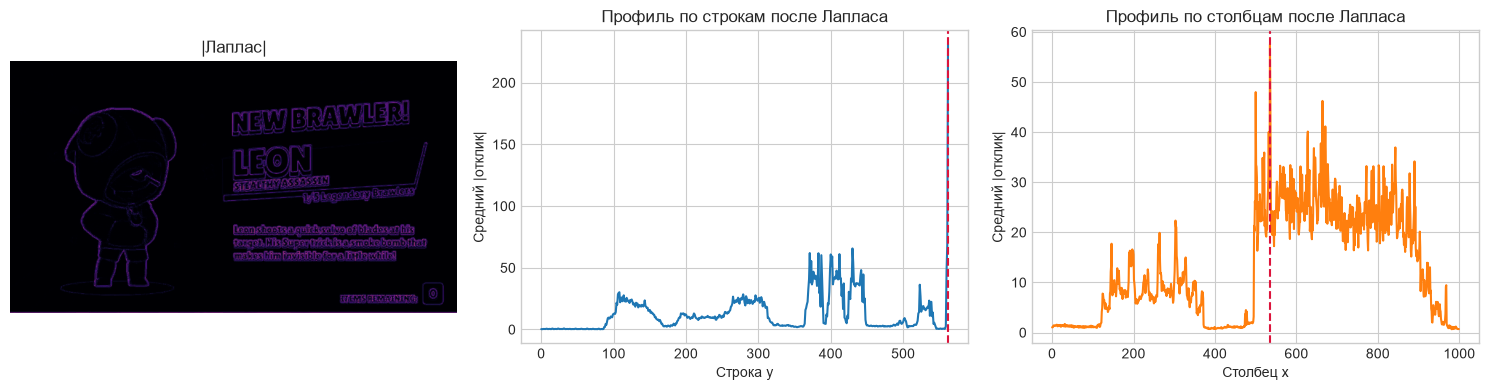

In [3]:
laplacian_signed = cv2.Laplacian(image, cv2.CV_64F)
laplacian = np.abs(laplacian_signed)
laplacian_horizontal_profile = laplacian.mean(axis=1)
laplacian_vertical_profile = laplacian.mean(axis=0)

max_lap_row = int(np.argmax(laplacian_horizontal_profile))
max_lap_col = int(np.argmax(laplacian_vertical_profile))
print(f'Максимум горизонтального профиля Лапласа: строка {max_lap_row}, {laplacian_horizontal_profile[max_lap_row]:.2f}')
print(f'Максимум вертикального профиля Лапласа: столбец {max_lap_col}, {laplacian_vertical_profile[max_lap_col]:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(laplacian, cmap='magma')
axes[0].set_title('|Лаплас|')
axes[0].axis('off')
axes[1].plot(laplacian_horizontal_profile, color='tab:blue')
axes[1].axvline(max_lap_row, color='crimson', linestyle='--')
axes[1].set_title('Профиль по строкам после Лапласа')
axes[1].set_xlabel('Строка y')
axes[1].set_ylabel('Средний |отклик|')
axes[2].plot(laplacian_vertical_profile, color='tab:orange')
axes[2].axvline(max_lap_col, color='crimson', linestyle='--')
axes[2].set_title('Профиль по столбцам после Лапласа')
axes[2].set_xlabel('Столбец x')
axes[2].set_ylabel('Средний |отклик|')
plt.tight_layout()
plt.show()

Максимум горизонтальной проекции: строка 86, 223754
Максимум вертикальной проекции: столбец 372, 129309


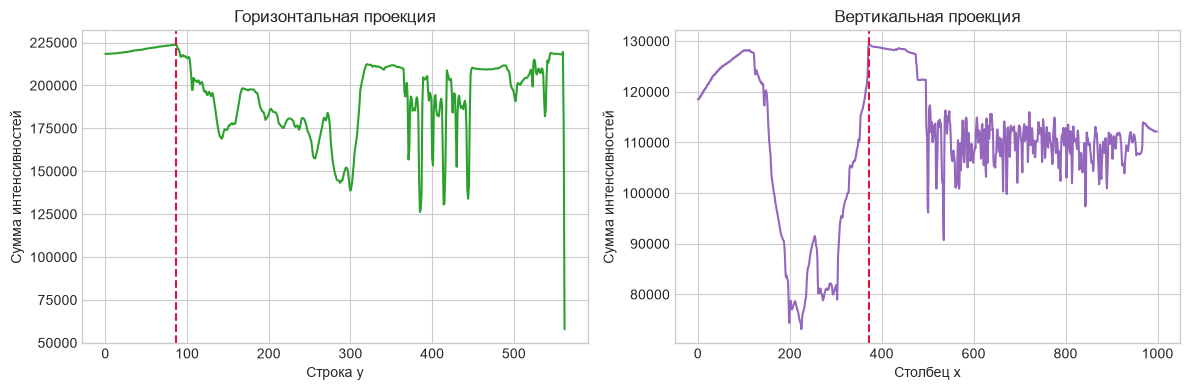

In [4]:
horizontal_projection = image.sum(axis=1)
vertical_projection = image.sum(axis=0)
max_projection_row = int(np.argmax(horizontal_projection))
max_projection_col = int(np.argmax(vertical_projection))
print(f'Максимум горизонтальной проекции: строка {max_projection_row}, {horizontal_projection[max_projection_row]:.0f}')
print(f'Максимум вертикальной проекции: столбец {max_projection_col}, {vertical_projection[max_projection_col]:.0f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(horizontal_projection, color='tab:green')
axes[0].axvline(max_projection_row, color='crimson', linestyle='--')
axes[0].set_title('Горизонтальная проекция')
axes[0].set_xlabel('Строка y')
axes[0].set_ylabel('Сумма интенсивностей')
axes[1].plot(vertical_projection, color='tab:purple')
axes[1].axvline(max_projection_col, color='crimson', linestyle='--')
axes[1].set_title('Вертикальная проекция')
axes[1].set_xlabel('Столбец x')
axes[1].set_ylabel('Сумма интенсивностей')
plt.tight_layout()
plt.show()

Порог Отсу: 141.00
Доля белых пикселей: 85.04%
Пик бинарной гистограммы: интенсивность 255, 478798 пикс.
Максимум бинарной горизонтальной проекции: строка 0
Максимум бинарной вертикальной проекции: столбец 0


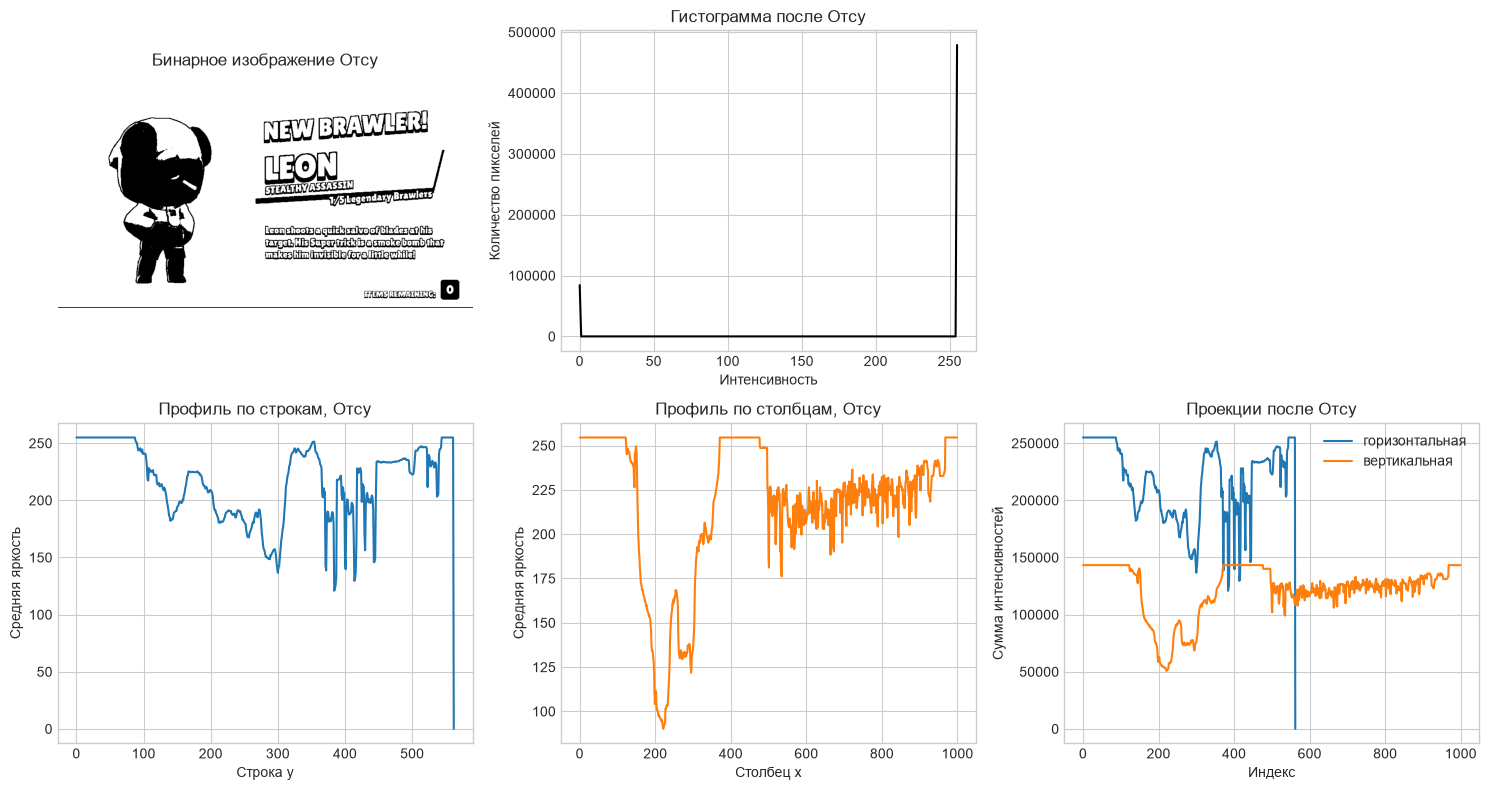

In [5]:
otsu_threshold, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
binary_histogram = cv2.calcHist([binary], [0], None, [256], [0, 256]).ravel()
binary_horizontal_profile = binary.mean(axis=1)
binary_vertical_profile = binary.mean(axis=0)
binary_horizontal_projection = binary.sum(axis=1)
binary_vertical_projection = binary.sum(axis=0)
binary_peak_intensity = int(np.argmax(binary_histogram))
binary_max_row = int(np.argmax(binary_horizontal_projection))
binary_max_col = int(np.argmax(binary_vertical_projection))
print(f'Порог Отсу: {otsu_threshold:.2f}')
print(f'Доля белых пикселей: {np.mean(binary == 255):.2%}')
print(f'Пик бинарной гистограммы: интенсивность {binary_peak_intensity}, {int(binary_histogram[binary_peak_intensity])} пикс.')
print(f'Максимум бинарной горизонтальной проекции: строка {binary_max_row}')
print(f'Максимум бинарной вертикальной проекции: столбец {binary_max_col}')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].imshow(binary, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Бинарное изображение Отсу')
axes[0, 0].axis('off')
axes[0, 1].plot(np.arange(256), binary_histogram, color='black')
axes[0, 1].set_title('Гистограмма после Отсу')
axes[0, 1].set_xlabel('Интенсивность')
axes[0, 1].set_ylabel('Количество пикселей')
axes[0, 2].axis('off')
axes[1, 0].plot(binary_horizontal_profile, color='tab:blue')
axes[1, 0].set_title('Профиль по строкам, Отсу')
axes[1, 0].set_xlabel('Строка y')
axes[1, 0].set_ylabel('Средняя яркость')
axes[1, 1].plot(binary_vertical_profile, color='tab:orange')
axes[1, 1].set_title('Профиль по столбцам, Отсу')
axes[1, 1].set_xlabel('Столбец x')
axes[1, 1].set_ylabel('Средняя яркость')
axes[1, 2].plot(binary_horizontal_projection, label='горизонтальная')
axes[1, 2].plot(binary_vertical_projection, label='вертикальная')
axes[1, 2].set_title('Проекции после Отсу')
axes[1, 2].set_xlabel('Индекс')
axes[1, 2].set_ylabel('Сумма интенсивностей')
axes[1, 2].legend()
plt.tight_layout()
plt.show()

## Ответы на контрольные вопросы

**1. Что такое гистограмма изображения и для чего она используется?**

Гистограмма изображения показывает, сколько пикселей имеют каждое значение яркости. Для полутонового изображения по горизонтальной оси откладываются значения от 0 до 255, а по вертикальной — количество пикселей. Гистограмма помогает оценить распределение яркости, найти преобладающие тона, определить недостаток контраста и выбрать порог для бинаризации.

**2. Чем отличается гистограмма цветного изображения от серого?**

У полутонового изображения строится одна гистограмма, потому что каждый пиксель имеет одно значение яркости. Для цветного изображения обычно строят отдельную гистограмму для каждого канала, например B, G и R в OpenCV. Эти гистограммы показывают распределение интенсивностей отдельных цветовых составляющих и не описывают цвет пикселя целиком.

**3. Что такое профиль изображения?**

Профиль изображения — это изменение некоторой характеристики вдоль одной координаты. Горизонтальный профиль показывает значения по строкам, а вертикальный — по столбцам. Профиль можно строить для яркости исходного изображения, отклика фильтра или другого числового показателя.

**4. Как вычисляется горизонтальный и вертикальный профиль?**

Для изображения $I(x, y)$ горизонтальный профиль вычисляется как среднее значение по каждой строке

Вертикальный профиль вычисляется как среднее значение по каждому столбцу

В NumPy этим формулам соответствуют операции image.mean(axis=1) для строк и image.mean(axis=0) для столбцов.

**5. Что такое проекция изображения?**

Проекция изображения — это сумма значений пикселей вдоль одного измерения. Горизонтальная проекция складывает значения каждой строки, а вертикальная — значения каждого столбца

Проекция показывает, какое суммарное количество яркости или белых пикселей приходится на каждую строку или столбец.

**6. В чём разница между профилем и проекцией изображения?**

Профиль использует среднее значение, поэтому он характеризует среднюю яркость строки или столбца и не зависит от их длины. Проекция использует сумму и показывает общий вклад всех пикселей. Для изображения фиксированного размера графики профиля и проекции имеют одинаковую форму, но отличаются масштабом: проекция равна профилю, умноженному на число пикселей в соответствующей строке или столбце.

**7. Как гистограмма помогает в улучшении контраста изображения?**

По гистограмме можно определить, в каком диапазоне сосредоточены значения яркости. Если они занимают небольшой диапазон, изображение выглядит малоконтрастным. Тогда можно растянуть этот диапазон на весь интервал от 0 до 255 или применить эквализацию гистограммы. Если гистограмма уже занимает почти весь диапазон, дополнительное растяжение может усилить шум и ухудшить изображение.

**8. Как можно использовать горизонтальные и вертикальные проекции бинарного изображения?**

В бинарном изображении проекции фактически подсчитывают количество белых пикселей в каждой строке и каждом столбце. По ним можно найти границы объекта, определить строки и столбцы с наибольшей концентрацией объекта, обнаружить текстовые строки и разделить изображение на области. В этой работе максимумы проекций показывают координаты строк и столбцов, где сосредоточено больше всего белых пикселей после метода Отсу.

**9. Как изменится гистограмма изображения после применения фильтра сглаживания?**

Сглаживание уменьшает резкие перепады яркости и шум. Поэтому крайние значения встречаются реже, а соседние уровни яркости становятся более распространёнными. Гистограмма обычно становится более плавной и менее «зубчатой», но её точная форма зависит от исходного изображения и вида фильтра. Сам диапазон значений может немного сузиться.

**10. Что показывает пик на гистограмме изображения?**

Пик показывает значение яркости, которое встречается чаще всего, или наиболее распространённый диапазон значений, если пик широкий. Например, высокий пик в области светлых тонов означает, что в изображении много светлых пикселей. Пик не обязательно соответствует самому важному объекту: он может быть связан с большим однородным фоном.